In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [70]:
import os
import numpy as np
import librosa as la
import matplotlib.pyplot as plt
import librosa.display
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,Dropout

In [4]:
main_folder_path="/content/drive/MyDrive/TESS Toronto emotional speech set data"

In [28]:
X=[]
Y=[]

for subfolder in os.listdir(main_folder_path):
  subfolder_path=os.path.join(main_folder_path,subfolder)
  for files in os.listdir(subfolder_path):
    files_path=os.path.join(subfolder_path,files)
    # load audio and get the waveform and sampling rate
    waveform,sampling_rate=la.load(files_path,sr=16000)
    # now compute mel spectrogram
    mel_spectrogram=la.feature.melspectrogram(
    y=waveform,
    sr=sampling_rate,
    n_mels=128
    )
    # convert to db human ear
    mel_db=la.power_to_db(mel_spectrogram,ref=np.max)
    # normalize the mel_db 0-1
    img=(mel_db -mel_db.min())/(mel_db.max()-mel_db.min())
    # now resize the image
    img=cv2.resize(img,(224,224))
    # now make 3 channel
    image=np.stack([img,img,img],axis=-1)

    X.append(image)
    Y.append(subfolder)


In [10]:
# load audio and get the waveform and sampling rate
waveform,sampling_rate=la.load(files_path,sr=16000)
print(f"waveform is:{waveform}")
print(f"sampling rate is: {sampling_rate}")

waveform is:[-4.6294917e-05 -8.3692808e-05 -1.2051407e-04 ...  2.7610827e-04
  2.6508217e-04  1.7618467e-04]
sampling rate is: 16000


In [12]:
# now compute mel spectrogram

mel_spectrogram=la.feature.melspectrogram(
    y=waveform,
    sr=sampling_rate,
    n_mels=128
)

mel_spectrogram

array([[7.8611402e-04, 9.5430035e-03, 2.3458583e-02, ..., 1.7277418e-02,
        9.0761436e-03, 6.3885595e-03],
       [4.2247304e-04, 1.0496373e-03, 4.9170502e-04, ..., 1.5952002e-03,
        5.8963062e-04, 2.8903104e-04],
       [7.5899574e-05, 3.0077327e-04, 1.3880208e-04, ..., 2.5251680e-05,
        1.8094101e-05, 3.6976187e-05],
       ...,
       [4.6343796e-08, 7.6855104e-06, 8.9317065e-05, ..., 5.0717125e-07,
        2.3091734e-07, 9.4662362e-08],
       [2.1249246e-08, 2.0080768e-06, 3.0041012e-05, ..., 1.8371102e-07,
        8.9773579e-08, 3.5465870e-08],
       [1.9855970e-09, 4.4190358e-08, 2.2082068e-06, ..., 1.5835527e-08,
        4.5523718e-09, 2.2269642e-09]], dtype=float32)

In [13]:
mel_db=la.power_to_db(mel_spectrogram,ref=np.max)
mel_db

array([[-47.42906 , -36.587067, -32.6809  , ..., -34.00913 , -36.804905,
        -38.329887],
       [-50.12593 , -46.173527, -49.466873, ..., -44.355766, -48.678116,
        -51.774475],
       [-57.581528, -51.601524, -54.95996 , ..., -62.361015, -63.808548,
        -60.704697],
       ...,
       [-80.      , -67.5272  , -56.87458 , ..., -79.332375, -80.      ,
        -80.      ],
       [-80.      , -73.35612 , -61.606773, ..., -80.      , -80.      ,
        -80.      ],
       [-80.      , -80.      , -72.94352 , ..., -80.      , -80.      ,
        -80.      ]], dtype=float32)

Text(0.5, 1.0, 'Mel Spectrogram')

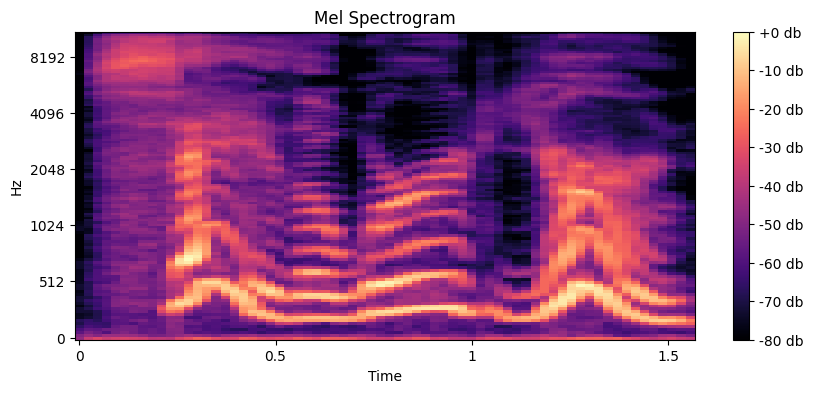

In [16]:
plt.figure(figsize=(10,4))
la.display.specshow(mel_db,x_axis="time",y_axis="mel")
plt.colorbar(format="%+2.0f db")
plt.title("Mel Spectrogram")

In [17]:
mel_db.shape

(128, 68)

In [21]:
# normalize the mel_db 0-1
img=(mel_db -mel_db.min())/(mel_db.max()-mel_db.min())


(128, 68)

In [22]:
# now resize the image
img=cv2.resize(img,(224,224))

In [25]:
# now make 3 channel
image=np.stack([img,img,img],axis=-1)

In [27]:
image.shape

(224, 224, 3)

In [33]:
# now convert lists into numpy array
X_array=np.array(X)
Y_array=np.array(Y)

print(f"X array shape is: {X_array.shape}")
print(f"Y array  shape is: {Y_array.shape}")

X array shape is: (2800, 224, 224, 3)
Y array  shape is: (2800,)


In [34]:
# first reshape the Y beacuse ohe expect 2d array
Y_arr=Y_array.reshape(-1,1)
# now use onehotencoder on Y
ohe=OneHotEncoder(sparse_output=False)
Y_transformed=ohe.fit_transform(Y_arr)


In [36]:
Y_transformed.shape

(2800, 14)

In [37]:
X_train,X_test,Y_train,Y_test=train_test_split(X_array,Y_transformed,test_size=0.2,random_state=42)

In [38]:
print(f"X_train shape is: {X_train.shape}")
print(f"X_test shape is: {X_test.shape}")
print(f"Y_train shape is: {Y_train.shape}")
print(f"Y_test shape is: {Y_test.shape}")

X_train shape is: (2240, 224, 224, 3)
X_test shape is: (560, 224, 224, 3)
Y_train shape is: (2240, 14)
Y_test shape is: (560, 14)


In [40]:
# now load VGG16 model
Conv_base_model=VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

#now freeze the Conv_base
Conv_base_model.trainable=False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [42]:
Conv_base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [43]:
model=Sequential()

model.add(Conv_base_model)

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(14,activation="softmax"))


In [44]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,927,886 (68.39 MB)

 Trainable params: 3,213,198 (12.26 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [45]:
for layer in Conv_base_model.layers:
    layer.trainable = False


In [46]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [47]:
history = model.fit(
    X_train, Y_train,
    validation_data=(X_test, Y_test),
    epochs=40,
    batch_size=32
)


Epoch 1/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 41s 347ms/step - accuracy: 0.4302 - loss: 2.1712 - val_accuracy: 0.9893 - val_loss: 0.1684
Epoch 2/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 16s 223ms/step - accuracy: 0.8711 - loss: 0.4275 - val_accuracy: 0.9982 - val_loss: 0.0518
Epoch 3/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 16s 226ms/step - accuracy: 0.9387 - loss: 0.2217 - val_accuracy: 0.9964 - val_loss: 0.0239
Epoch 4/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 16s 222ms/step - accuracy: 0.9550 - loss: 0.1676 - val_accuracy: 0.9964 - val_loss: 0.0122
Epoch 5/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 216ms/step - accuracy: 0.9659 - loss: 0.1237 - val_accuracy: 0.9982 - val_loss: 0.0092
Epoch 6/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 216ms/step - accuracy: 0.9582 - loss: 0.1123 - val_accuracy: 0.9982 - val_loss: 0.0067
Epoch 7/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 219ms/step - accuracy: 0.9675 - loss: 0.1027 - val_accuracy: 0.9982 - val_loss: 0.0048
Epoch 8/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 221ms/step - accuracy: 0.9640 - loss: 0.0979 - val_accu

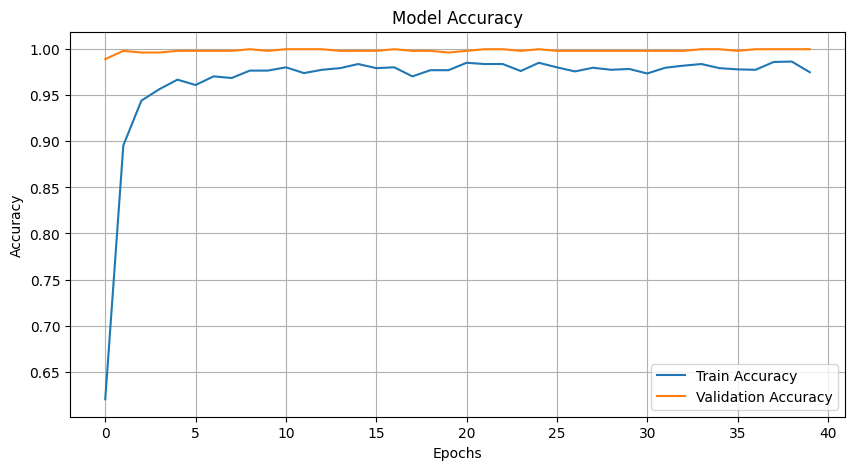

In [69]:
# Training & Validation Accuracy
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


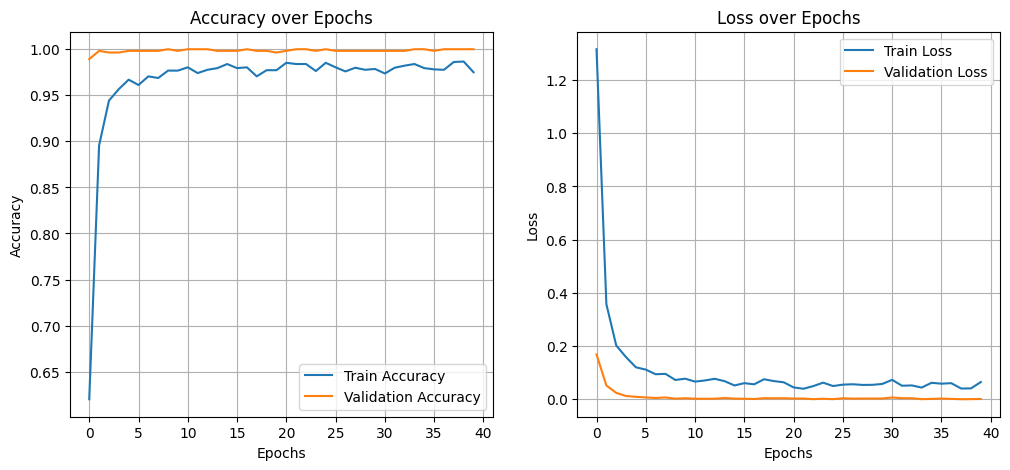

In [68]:
plt.figure(figsize=(12,5))

# Subplot 1: Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Subplot 2: Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
